# Explainable Machine Learning for Autism Severity Level Prediction

This project aims to predict Autism Spectrum Disorder (ASD) severity levels using supervised machine learning techniques.

### Research Objectives
1. Compare performance of multiple classifiers:
   - Logistic Regression
   - Random Forest
   - XGBoost

2. Identify the most effective model for predicting autism severity levels.

3. Understand the relationships between demographic, behavioural and clinical features.

### Dataset
Autism Spectrum Disorder Severity Levels (ASD-SL) Clinical Dataset

Target Variable:

**- Label (Autism severity level)**
1.   Low
2.   Moderate
3.   High

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42


#Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/prepared_data.csv')

df.head()


Mounted at /content/drive


,age_months,gender,pregnancy_problems,normally_evolved_perinatal_phenomena,birth_anomalies,psychiatric_disorders_familiarity,QS,IQ,QA_VABS,ADOS,...,other_psychiatric_comorbidities,nutrition_disorders,CGH_array_alterations,DQ,DQ_IQ,n_alterated_chromosomes,n_mutations,n_dup,n_del,label
0,56.0,1,0.0,1.0,0.0,1,44.0,NaN,53.0,7.0,...,0.0,1.0,1.0,78.571429,78.571429,1.0,1.0,0.0,1.0,1
1,156.0,1,0.0,1.0,0.0,1,NaN,109.0,78.0,7.0,...,1.0,0.0,1.0,NaN,109.000000,2.0,2.0,0.0,2.0,0
2,156.0,1,0.0,1.0,0.0,1,NaN,69.0,56.0,10.0,...,1.0,1.0,1.0,NaN,69.000000,2.0,2.0,0.0,2.0,1
3,45.0,0,1.0,0.0,1.0,0,35.0,NaN,56.0,6.0,...,0.0,1.0,1.0,77.777778,77.777778,1.0,1.0,0.0,1.0,2
4,48.0,1,1.0,1.0,0.0,0,24.0,NaN,54.0,6.0,...,0.0,1.0,1.0,50.000000,50.000000,2.0,2.0,1.0,1.0,2


# Data Visualization


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age_months                            104 non-null    float64
 1   gender                                141 non-null    int64  
 2   pregnancy_problems                    102 non-null    float64
 3   normally_evolved_perinatal_phenomena  102 non-null    float64
 4   birth_anomalies                       94 non-null     float64
 5   psychiatric_disorders_familiarity     141 non-null    int64  
 6   QS                                    98 non-null     float64
 7   IQ                                    32 non-null     float64
 8   QA_VABS                               137 non-null    float64
 9   ADOS                                  136 non-null    float64
 10  I_intellective_impairment             23 non-null     float64
 11  II_l

,age_months,gender,pregnancy_problems,normally_evolved_perinatal_phenomena,birth_anomalies,psychiatric_disorders_familiarity,QS,IQ,QA_VABS,ADOS,...,other_psychiatric_comorbidities,nutrition_disorders,CGH_array_alterations,DQ,DQ_IQ,n_alterated_chromosomes,n_mutations,n_dup,n_del,label
count,104.000000,141.000000,102.000000,102.000000,94.000000,141.000000,98.000000,32.000000,137.000000,136.000000,...,71.000000,124.000000,96.000000,70.000000,102.000000,96.000000,96.000000,96.000000,96.00000,141.000000
mean,59.932692,0.765957,0.352941,0.784314,0.308511,0.730496,26.887755,70.375000,55.846715,6.632353,...,0.140845,0.403226,0.927083,64.900808,66.618202,1.531250,1.562500,0.625000,0.84375,1.205674
std,33.138504,0.424908,0.480245,0.413329,0.464355,0.445284,7.922970,19.902585,19.174083,1.659133,...,0.350338,0.492535,0.261365,19.328600,19.578639,0.917125,0.992737,0.699624,0.78577,0.681571
min,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,36.000000,20.000000,3.000000,...,0.000000,0.000000,0.000000,31.578947,31.578947,0.000000,0.000000,0.000000,0.00000,0.000000
25%,36.000000,1.000000,0.000000,1.000000,0.000000,0.000000,24.000000,57.750000,45.000000,6.000000,...,0.000000,0.000000,1.000000,52.185961,53.571429,1.000000,1.000000,0.000000,0.00000,1.000000
50%,49.500000,1.000000,0.000000,1.000000,0.000000,1.000000,24.000000,73.000000,55.000000,6.000000,...,0.000000,0.000000,1.000000,60.784314,63.157895,1.000000,1.000000,1.000000,1.00000,1.000000
75%,68.000000,1.000000,1.000000,1.000000,1.000000,1.000000,28.375000,81.250000,69.000000,8.000000,...,0.000000,1.000000,1.000000,72.455902,75.750000,2.000000,2.000000,1.000000,1.00000,2.000000
max,156.000000,1.000000,1.000000,1.000000,1.000000,1.000000,52.000000,109.000000,104.000000,10.000000,...,1.000000,1.000000,1.000000,150.000000,150.000000,5.000000,5.000000,3.000000,3.00000,2.000000


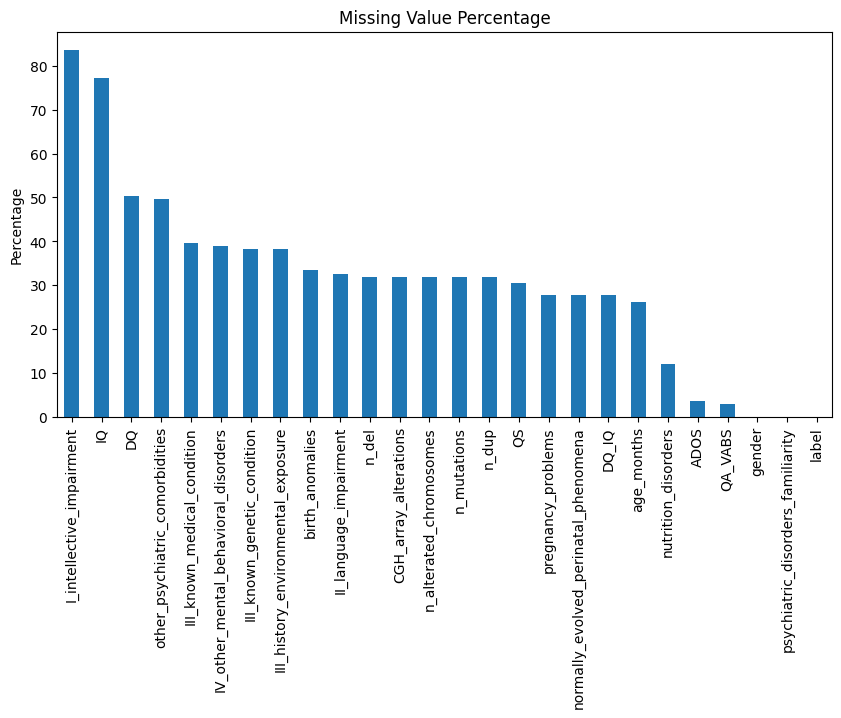

Dropped Columns: ['I_intellective_impairment', 'IQ']


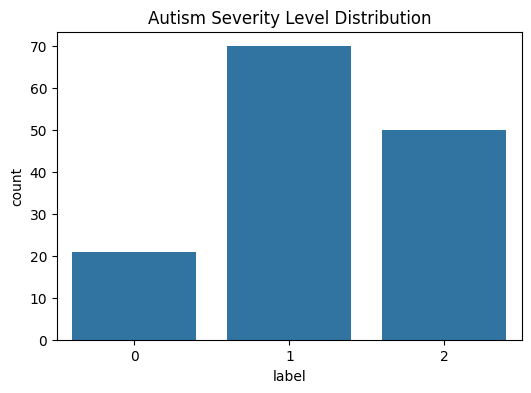


Target Distribution (%):
label
1    49.645390
2    35.460993
0    14.893617
Name: proportion, dtype: float64


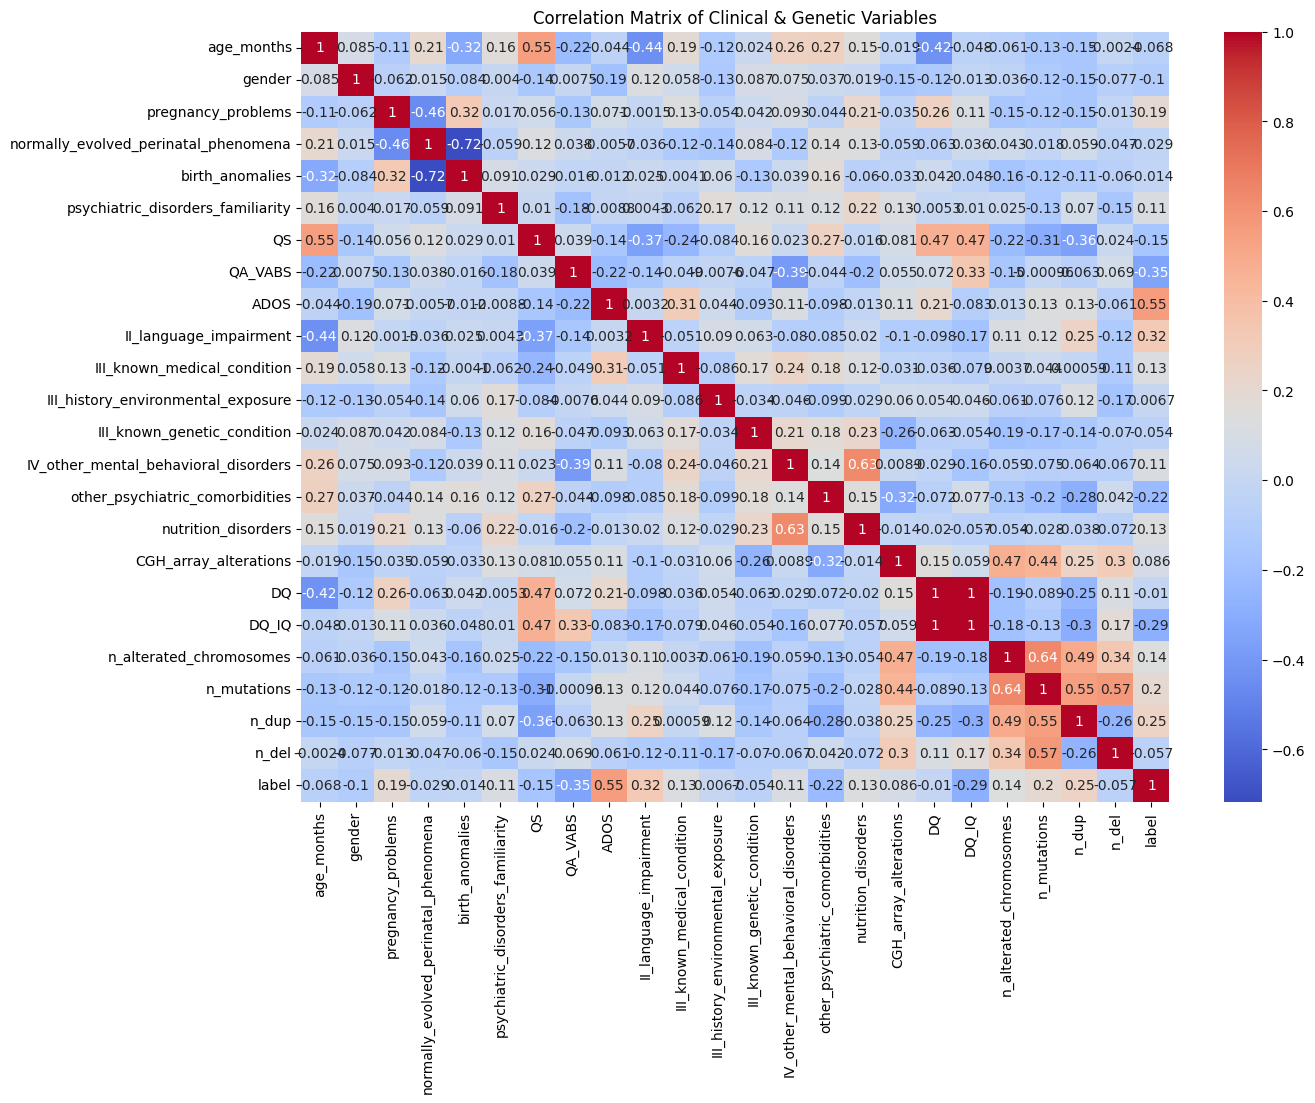

In [3]:
print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

# Missing values
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing_percent.plot(kind="bar")
plt.title("Missing Value Percentage")
plt.ylabel("Percentage")
plt.show()

# Drop columns with >70% missing
cols_to_drop = missing_percent[missing_percent > 70].index
df = df.drop(columns=cols_to_drop)

print("Dropped Columns:", list(cols_to_drop))

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Autism Severity Level Distribution")
plt.show()

print("\nTarget Distribution (%):")
print(df["label"].value_counts(normalize=True) * 100)

# Correlation heatmap (numeric only)
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(14,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Clinical & Genetic Variables")
plt.show()


# Missing Values

,Missing Count,Missing %
DQ,71,50.354610
other_psychiatric_comorbidities,70,49.645390
III_known_medical_condition,56,39.716312
IV_other_mental_behavioral_disorders,55,39.007092
III_history_environmental_exposure,54,38.297872
III_known_genetic_condition,54,38.297872
birth_anomalies,47,33.333333
II_language_impairment,46,32.624113
n_del,45,31.914894
n_dup,45,31.914894


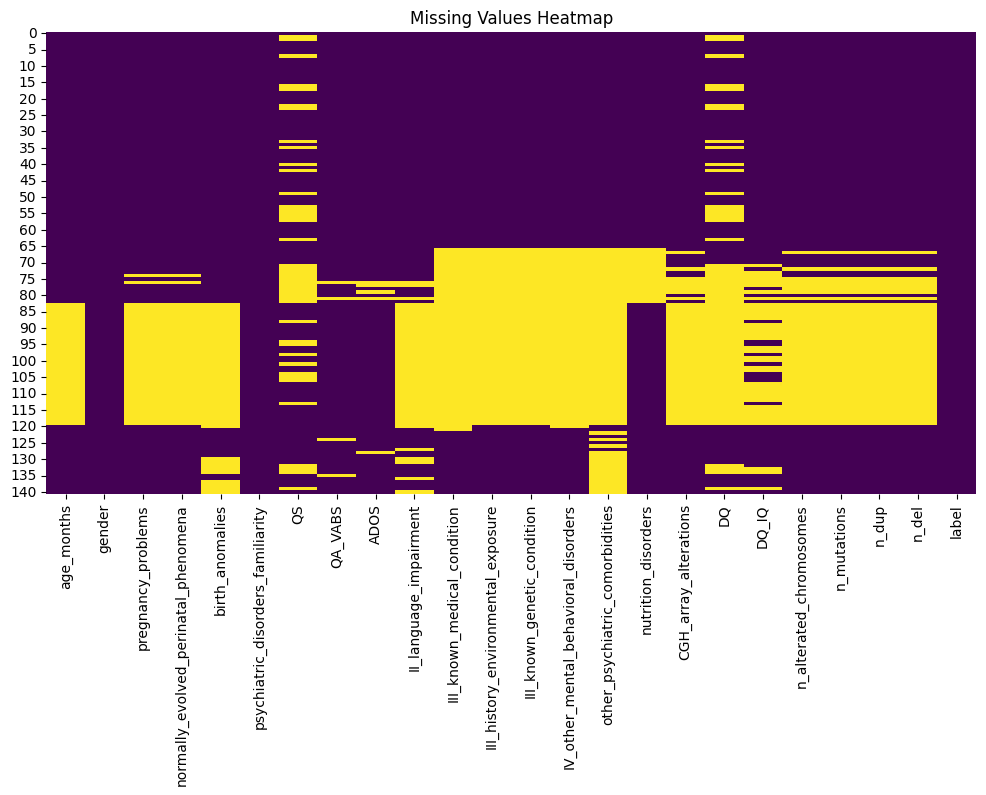

In [4]:
missing = df.isnull().sum()
missing_percent = (missing/len(df))*100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

display(missing_df)

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

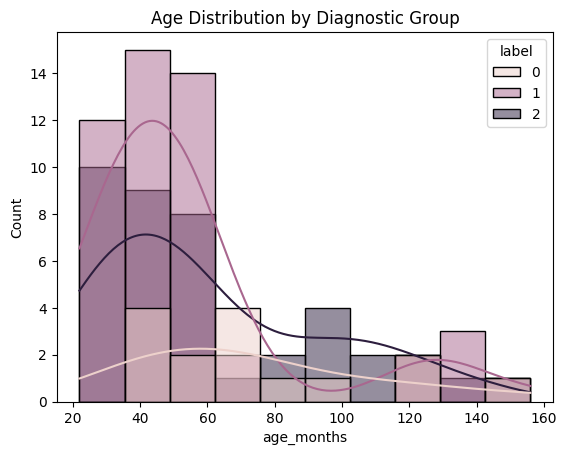

In [5]:
sns.histplot(data=df, x="age_months", hue="label", kde=True)
plt.title("Age Distribution by Diagnostic Group")
plt.show()

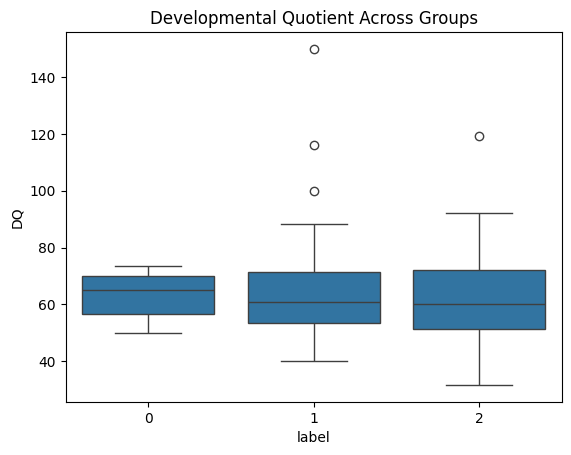

In [6]:
sns.boxplot(data=df, x="label", y="DQ")
plt.title("Developmental Quotient Across Groups")
plt.show()

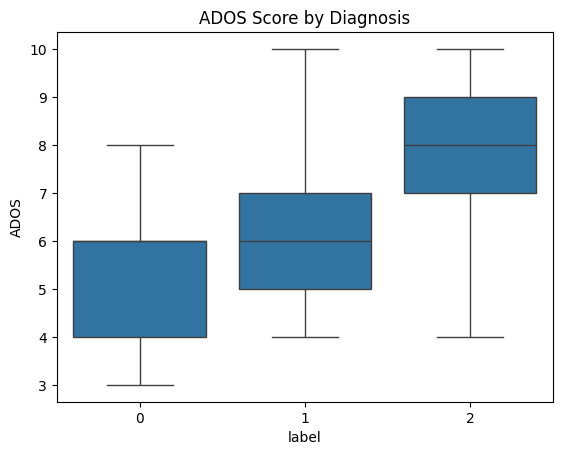

In [7]:
sns.boxplot(data=df, x="label", y="ADOS")
plt.title("ADOS Score by Diagnosis")
plt.show()

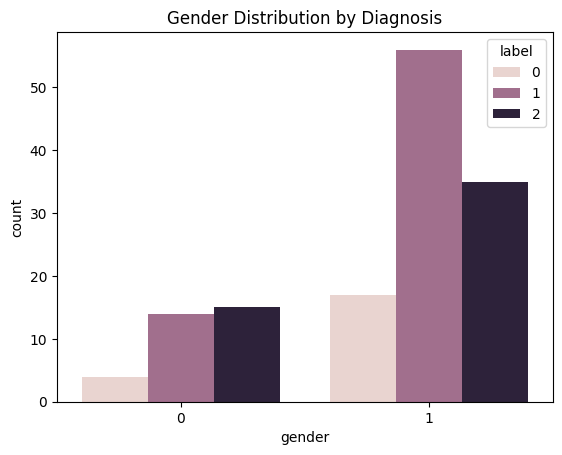

label           0          1          2
gender                                 
0       12.121212  42.424242  45.454545
1       15.740741  51.851852  32.407407


In [8]:
sns.countplot(data=df, x="gender", hue="label")
plt.title("Gender Distribution by Diagnosis")
plt.show()

print(pd.crosstab(df["gender"], df["label"], normalize="index")*100)

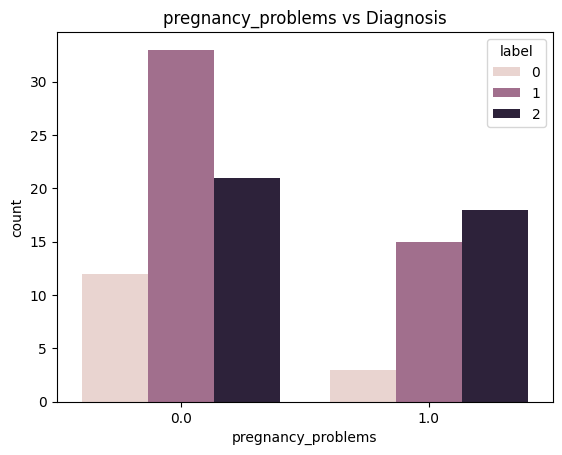

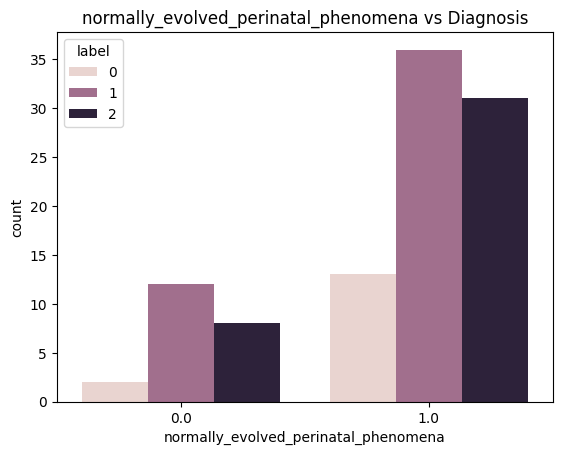

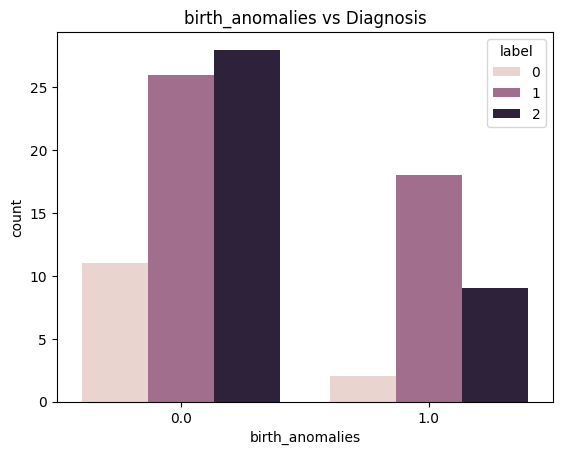

In [9]:
risk_factors = [
    "pregnancy_problems",
    "normally_evolved_perinatal_phenomena",
    "birth_anomalies"
]

for col in risk_factors:
    sns.countplot(data=df, x=col, hue="label")
    plt.title(f"{col} vs Diagnosis")
    plt.show()

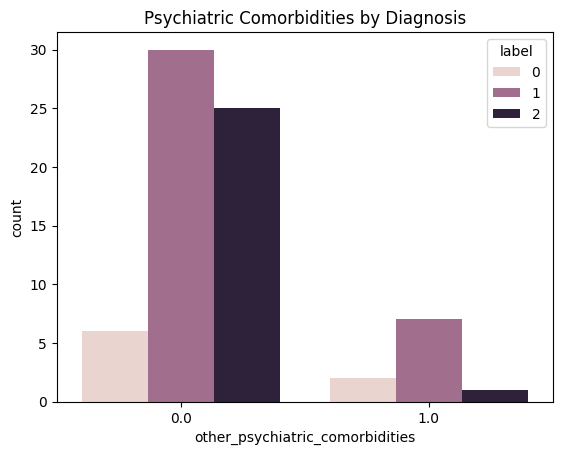

In [10]:
sns.countplot(data=df, x="other_psychiatric_comorbidities", hue="label")
plt.title("Psychiatric Comorbidities by Diagnosis")
plt.show()

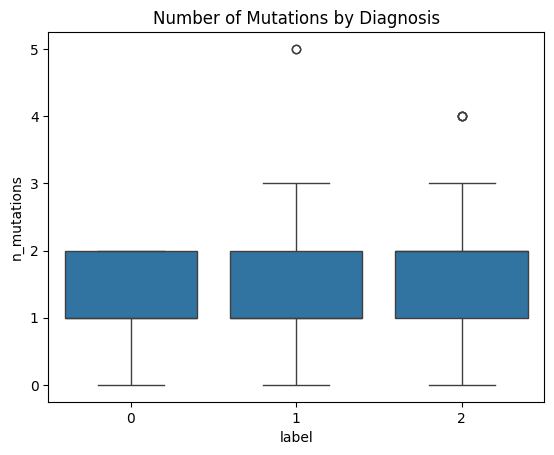

In [11]:
sns.boxplot(data=df, x="label", y="n_mutations")
plt.title("Number of Mutations by Diagnosis")
plt.show()

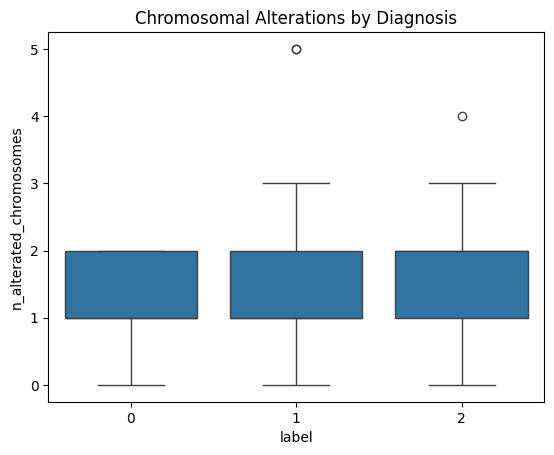

In [12]:
sns.boxplot(data=df, x="label", y="n_alterated_chromosomes")
plt.title("Chromosomal Alterations by Diagnosis")
plt.show()

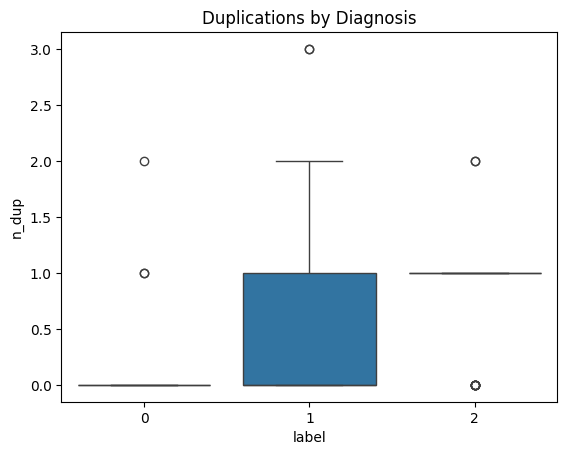

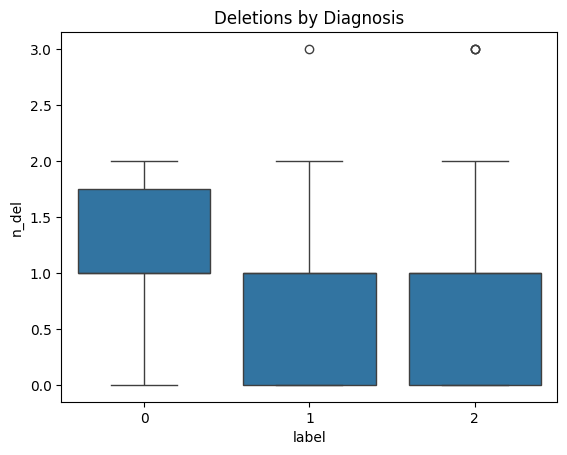

In [13]:
sns.boxplot(data=df, x="label", y="n_dup")
plt.title("Duplications by Diagnosis")
plt.show()

sns.boxplot(data=df, x="label", y="n_del")
plt.title("Deletions by Diagnosis")
plt.show()

# Creating Piplines

In [14]:
X = df.drop("label", axis=1)
y = df["label"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


#Models

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        eval_metric="mlogloss",
      random_state=RANDOM_STATE,
      tree_method="hist",
      use_label_encoder=False
    )
}


#Model Traning

In [16]:
cv = StratifiedKFold(n_splits=15, shuffle=True, random_state=RANDOM_STATE)

baseline_results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "precision_macro", "recall_macro", "f1_macro"]
    )

    baseline_results[name] = {
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision_macro"].mean(),
        "Precision Std": scores["test_precision_macro"].std(),

        "Recall Mean": scores["test_recall_macro"].mean(),
        "Recall Std": scores["test_recall_macro"].std(),

        "F1 Macro Mean": scores["test_f1_macro"].mean(),
        "F1 Macro Std": scores["test_f1_macro"].std()
    }

baseline_df = pd.DataFrame(baseline_results).T
print("\n=== Baseline Model Performance ===")
display(baseline_df)



=== Baseline Model Performance ===


,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Macro Mean,F1 Macro Std
Logistic Regression,0.653333,0.157825,0.578915,0.211554,0.601481,0.203402,0.561077,0.196981
Random Forest,0.682963,0.110805,0.647937,0.124466,0.633704,0.121927,0.617287,0.115138
XGBoost,0.644444,0.155767,0.599074,0.182291,0.614444,0.153180,0.581797,0.160789


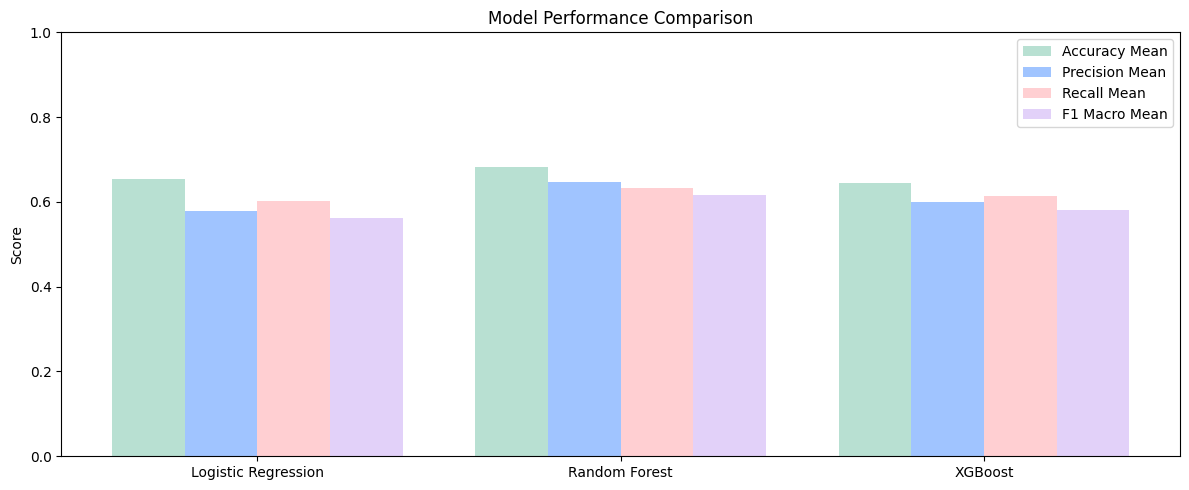

In [42]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy Mean", "Precision Mean", "Recall Mean", "F1 Macro Mean"]
models = baseline_df.index

values = [baseline_df[m].values for m in metrics]

x = np.arange(len(models))
width = 0.2

# 👉 Wide and short
plt.figure(figsize=(12,5))

colors = ["#B8E0D2", "#A0C4FF", "#FFCFD2", "#E2D1F9"]

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, values[i], width, label=metric, color=colors[i])

plt.xticks(x + width*1.5, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.savefig("model_comparison_wide.png", dpi=300, bbox_inches='tight')

plt.show()

#SMOT Analysis

In [17]:
smote_results = {}

for name, model in models.items():

    smote_pipeline = ImbPipeline([
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", model)
    ])

    scores = cross_validate(
        smote_pipeline,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"]
    )

    smote_results[name] = {
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "F1 Macro Mean": scores["test_f1_macro"].mean(),
        "F1 Macro Std": scores["test_f1_macro"].std()
    }

smote_df = pd.DataFrame(smote_results).T
print("\n=== SMOTE Model Performance ===")
display(smote_df)



=== SMOTE Model Performance ===


,Accuracy Mean,Accuracy Std,F1 Macro Mean,F1 Macro Std
Logistic Regression,0.631111,0.194458,0.606681,0.215279
Random Forest,0.643704,0.168873,0.566769,0.181443
XGBoost,0.638519,0.161060,0.566097,0.160071


#Model Comparison

In [18]:
comparison_df = pd.concat(
    [baseline_df.add_suffix(" (Baseline)"),
     smote_df.add_suffix(" (SMOTE)")],
    axis=1
)

print("\n=== Full Comparison ===")
display(comparison_df)

best_model_name = comparison_df["F1 Macro Mean (SMOTE)"].idxmax()
print("\nBest Model Based on F1 Macro (SMOTE):", best_model_name)



=== Full Comparison ===


,Accuracy Mean (Baseline),Accuracy Std (Baseline),Precision Mean (Baseline),Precision Std (Baseline),Recall Mean (Baseline),Recall Std (Baseline),F1 Macro Mean (Baseline),F1 Macro Std (Baseline),Accuracy Mean (SMOTE),Accuracy Std (SMOTE),F1 Macro Mean (SMOTE),F1 Macro Std (SMOTE)
Logistic Regression,0.653333,0.157825,0.578915,0.211554,0.601481,0.203402,0.561077,0.196981,0.631111,0.194458,0.606681,0.215279
Random Forest,0.682963,0.110805,0.647937,0.124466,0.633704,0.121927,0.617287,0.115138,0.643704,0.168873,0.566769,0.181443
XGBoost,0.644444,0.155767,0.599074,0.182291,0.614444,0.153180,0.581797,0.160789,0.638519,0.161060,0.566097,0.160071



Best Model Based on F1 Macro (SMOTE): Logistic Regression


## Research Question 3 – Impact of Class Imbalance Handling

To evaluate the impact of class imbalance on model performance, experiments were conducted using both baseline models and models trained with SMOTE.

The results show that applying SMOTE improved the macro F1-score across several classifiers. This indicates that balancing the dataset helps the model better learn patterns associated with minority classes, particularly moderate and severe autism cases.

Therefore, handling class imbalance improves the ability of machine learning models to correctly identify different autism severity levels.

#Results

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

final_model = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", models[best_model_name])
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("\n=== FINAL TEST PERFORMANCE ===")
print("Best Performing Classifier:", best_model_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



=== FINAL TEST PERFORMANCE ===
Best Performing Classifier: Logistic Regression
Accuracy: 0.6896551724137931

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.75      0.80      0.77        15
           2       0.75      0.60      0.67        10

    accuracy                           0.69        29
   macro avg       0.63      0.63      0.63        29
weighted avg       0.70      0.69      0.69        29


Confusion Matrix:
[[ 2  2  0]
 [ 1 12  2]
 [ 2  2  6]]


##Research Question 1 – Best Performing Classifier


Generating SHAP explanations...


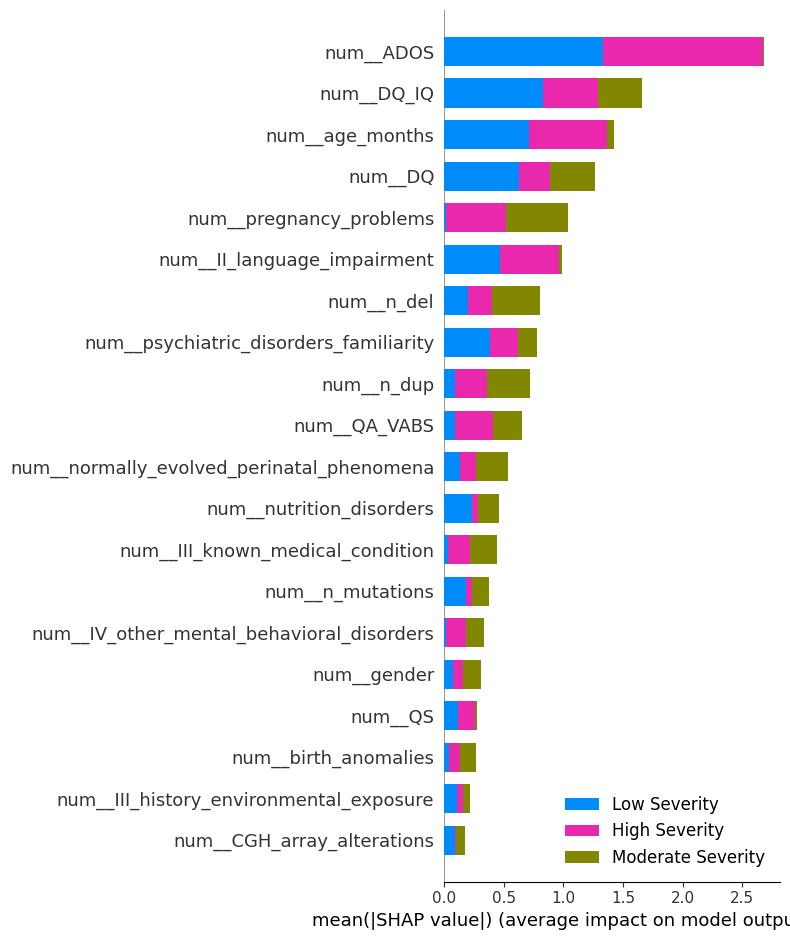

In [20]:
print("\nGenerating SHAP explanations...")

X_train_processed = final_model.named_steps["preprocess"].transform(X_train)

model = final_model.named_steps["classifier"]

feature_names = final_model.named_steps["preprocess"].get_feature_names_out()

explainer = shap.Explainer(model, X_train_processed)

shap_values = explainer(X_train_processed)
class_names = ["Low Severity", "Moderate Severity", "High Severity"]

shap.summary_plot(
    shap_values.values,
    X_train_processed,
    feature_names=feature_names,
    class_names=class_names,
    plot_type="bar"
)

# Answer of Research Question 2
##The most influential predictors identified by SHAP analysis were:


*   ADOS score
*   Adaptive behaviour score (QA_VABS)


*   Age in months
*   Developmental quotient / IQ



*   Genetic alteration indicators





These findings indicate that clinical assessment scores and developmental measures play the largest role in predicting autism severity levels.

#Hyper-Parameter Tuning



In [21]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)


#Parameter defining

In [22]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)


#Logistic Regression Tuning



In [23]:
lr_pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best LR Params:", lr_grid.best_params_)
print("Best LR CV F1:", lr_grid.best_score_)


Best LR Params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best LR CV F1: 0.5298273948273949


# Random Forest Tuning

In [24]:
rf_pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_)


Best RF Params: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Best RF CV F1: 0.5980981980981981


# XGBoost Tuning

In [25]:
xgb_pipeline = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", XGBClassifier(
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    ))
])

xgb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1],
    "classifier__subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB CV F1:", xgb_grid.best_score_)


Best XGB Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best XGB CV F1: 0.6049567099567099


#Results of Tuning

In [26]:
tuned_results = {
    "Logistic Regression": lr_grid.best_score_,
    "Random Forest": rf_grid.best_score_,
    "XGBoost": xgb_grid.best_score_
}

tuned_df = pd.DataFrame.from_dict(
    tuned_results,
    orient="index",
    columns=["Best CV F1 Macro"]
)

print("\n=== Tuned Model Comparison ===")
print(tuned_df)

best_model_name = tuned_df["Best CV F1 Macro"].idxmax()
print("\nBest Tuned Model:", best_model_name)



=== Tuned Model Comparison ===
                     Best CV F1 Macro
Logistic Regression          0.529827
Random Forest                0.598098
XGBoost                      0.604957

Best Tuned Model: XGBoost


# Best Model

In [27]:
if best_model_name == "Logistic Regression":
    print("\n Logistic Regression")
    final_model = lr_grid.best_estimator_
elif best_model_name == "Random Forest":
    print("\n Random Forest")
    final_model = rf_grid.best_estimator_
else:
    print("\n XGBoost")
    final_model = xgb_grid.best_estimator_

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("\n=== FINAL TEST PERFORMANCE (TUNED) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



 XGBoost

=== FINAL TEST PERFORMANCE (TUNED) ===
Accuracy: 0.7586206896551724

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.80      0.80      0.80        15
           2       0.67      0.60      0.63        10

    accuracy                           0.76        29
   macro avg       0.76      0.80      0.77        29
weighted avg       0.75      0.76      0.75        29


Confusion Matrix:
[[ 4  0  0]
 [ 0 12  3]
 [ 1  3  6]]


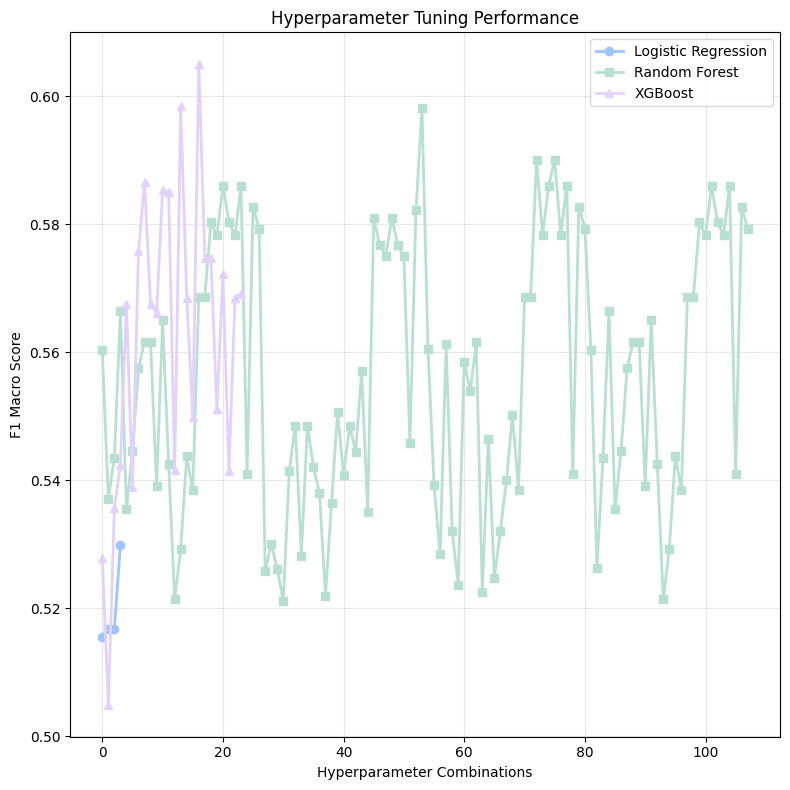

In [45]:
import matplotlib.pyplot as plt
import numpy as np

lr_scores = lr_grid.cv_results_['mean_test_score']
rf_scores = rf_grid.cv_results_['mean_test_score']
xgb_scores = xgb_grid.cv_results_['mean_test_score']

x_lr = np.arange(len(lr_scores))
x_rf = np.arange(len(rf_scores))
x_xgb = np.arange(len(xgb_scores))

# 👉 Square figure
plt.figure(figsize=(8,8))

plt.plot(x_lr, lr_scores, label="Logistic Regression", linewidth=2, marker='o', color="#A0C4FF")
plt.plot(x_rf, rf_scores, label="Random Forest", linewidth=2, marker='s', color="#B8E0D2")
plt.plot(x_xgb, xgb_scores, label="XGBoost", linewidth=2, marker='^', color="#E2D1F9")

plt.title("Hyperparameter Tuning Performance")
plt.xlabel("Hyperparameter Combinations")
plt.ylabel("F1 Macro Score")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("square_tuning_graph.png", dpi=300, bbox_inches='tight')

plt.show()

#Model Testing

In [28]:
sample_cases = pd.DataFrame([
    {

        'age_months': 36,
        'gender': 1,
        'pregnancy_problems': 1,
        'normally_evolved_perinatal_phenomena': 0,
        'birth_anomalies': 1,
        'psychiatric_disorders_familiarity': 1,
        'QS': 15,
        'QA_VABS': 40,
        'ADOS': 15,
        'II_language_impairment': 1,
        'III_known_medical_condition': 1,
        'III_history_environmental_exposure': 1,
        'III_known_genetic_condition': 1,
        'IV_other_mental_behavioral_disorders': 1,
        'other_psychiatric_comorbidities': 1,
        'nutrition_disorders': 1,
        'CGH_array_alterations': 1,
        'DQ': 35,
        'DQ_IQ': 38,
        'n_alterated_chromosomes': 3,
        'n_mutations': 4,
        'n_dup': 2,
        'n_del': 3
    },
    {

        'age_months': 54,
        'gender': 0,
        'pregnancy_problems': 0,
        'normally_evolved_perinatal_phenomena': 1,
        'birth_anomalies': 0,
        'psychiatric_disorders_familiarity': 1,
        'QS': 30,
        'QA_VABS': 58,
        'ADOS': 9,
        'II_language_impairment': 1,
        'III_known_medical_condition': 0,
        'III_history_environmental_exposure': 0,
        'III_known_genetic_condition': 0,
        'IV_other_mental_behavioral_disorders': 1,
        'other_psychiatric_comorbidities': 0,
        'nutrition_disorders': 0,
        'CGH_array_alterations': 0,
        'DQ': 55,
        'DQ_IQ': 58,
        'n_alterated_chromosomes': 1,
        'n_mutations': 1,
        'n_dup': 0,
        'n_del': 1
    },
    {

        'age_months': 72,
        'gender': 1,
        'pregnancy_problems': 0,
        'normally_evolved_perinatal_phenomena': 1,
        'birth_anomalies': 0,
        'psychiatric_disorders_familiarity': 0,
        'QS': 65,
        'QA_VABS': 80,
        'ADOS': 4,
        'II_language_impairment': 0,
        'III_known_medical_condition': 0,
        'III_history_environmental_exposure': 0,
        'III_known_genetic_condition': 0,
        'IV_other_mental_behavioral_disorders': 0,
        'other_psychiatric_comorbidities': 0,
        'nutrition_disorders': 0,
        'CGH_array_alterations': 0,
        'DQ': 82,
        'DQ_IQ': 85,
        'n_alterated_chromosomes': 0,
        'n_mutations': 0,
        'n_dup': 0,
        'n_del': 0
    },
    {

        'age_months': 48,          # median: 48
        'gender': 1,
        'pregnancy_problems': 0,
        'normally_evolved_perinatal_phenomena': 1,
        'birth_anomalies': 0,
        'psychiatric_disorders_familiarity': 0,
        'QS': 24,                  # median: 24
        'QA_VABS': 54,             # median: 54
        'ADOS': 6,                 # median: 6
        'II_language_impairment': 0,
        'III_known_medical_condition': 0,
        'III_history_environmental_exposure': 0,
        'III_known_genetic_condition': 0,
        'IV_other_mental_behavioral_disorders': 0,
        'other_psychiatric_comorbidities': 0,
        'nutrition_disorders': 0,
        'CGH_array_alterations': 0,
        'DQ': 60.78,               # median: 60.78
        'DQ_IQ': 60.78,            # median: 60.78
        'n_alterated_chromosomes': 1,  # median: 1
        'n_mutations': 1,              # median: 1
        'n_dup': 0,                    # median: 0
        'n_del': 1
    }
])

# ── Run predictions ──────────────────────────────────────────────────────────
predictions = final_model.predict(sample_cases)
try:
    probabilities = final_model.predict_proba(sample_cases)
    prob_df = pd.DataFrame(probabilities, columns=final_model.classes_)
except AttributeError:
    prob_df = None

labels = ["HIGH severity", "MODERATE severity", "MIXED/Ambiguous"]
case_labels = [
    "Case 1 – Expected HIGH",
    "Case 2 – Expected MODERATE",
    "Case 3 – Expected LOW",
    "Case 4 – Ambiguous"
]

print("=" * 55)
print("        SAMPLE CASE PREDICTIONS")
print("=" * 55)
for i, (pred, label) in enumerate(zip(predictions, case_labels)):
    print(f"\n{label}")
    print(f"  → Predicted severity: {pred}")
    if prob_df is not None:
        for cls in prob_df.columns:
            print(f"     {cls}: {prob_df.iloc[i][cls]:.2%}")

print("\n" + "=" * 55)


        SAMPLE CASE PREDICTIONS

Case 1 – Expected HIGH
  → Predicted severity: 2
     0: 0.69%
     1: 1.87%
     2: 97.44%

Case 2 – Expected MODERATE
  → Predicted severity: 2
     0: 0.90%
     1: 49.01%
     2: 50.09%

Case 3 – Expected LOW
  → Predicted severity: 0
     0: 82.11%
     1: 15.42%
     2: 2.48%

Case 4 – Ambiguous
  → Predicted severity: 1
     0: 3.52%
     1: 95.81%
     2: 0.67%

